CubicSpline
MSE: 0.0
R^2: 1.0

Polyfit
MSE: 0.16931216931216939
R^2: 0.32275132275132246

Cubic spline better


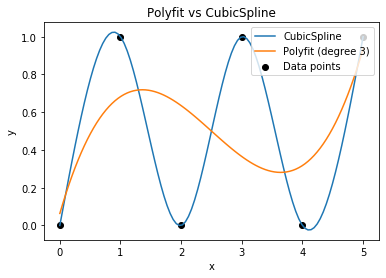

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

#Cubic spline
cs = CubicSpline(x, y, bc_type='natural')

x_interp = np.linspace(0, 5, 100)
y_spline = cs(x_interp)

y_spline_points = cs(x)

# Polyfit (cubic)
coeff = np.polyfit(x, y, 3)
poly = np.poly1d(coeff)

y_poly = poly(x_interp)

y_poly_points = poly(x)

def metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r2 = 1 - ss_res / ss_tot
    return mse, r2

mse_spline, r2_spline = metrics(y, y_spline_points)
mse_poly, r2_poly = metrics(y, y_poly_points)

print("CubicSpline")
print("MSE:", mse_spline)
print("R^2:", r2_spline)
print()

print("Polyfit")
print("MSE:", mse_poly)
print("R^2:", r2_poly)
print()

if mse_spline < mse_poly and r2_spline > r2_poly:
    print("Cubic spline better")
elif mse_poly < mse_spline and r2_poly > r2_spline:
    print("Polyfit is better")
else:
    print("Both methods are good")

plt.scatter(x, y, color='black', label='Data points')
plt.plot(x_interp, y_spline, label='CubicSpline')
plt.plot(x_interp, y_poly, label='Polyfit (degree 3)')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polyfit vs CubicSpline")
plt.legend()
plt.show()